# Sirroz bemorlari omon qolish prognozi — Kaggle submission

**Musobaqa:** [Multi-Class Prediction of Cirrhosis Outcomes](https://www.kaggle.com/competitions/multiclassificationtask) (Playground Series S3E26)

**Masala:** har bir bemor uchun 3 ta holatdan biriga ehtimollik berish kerak:
- `C` — tirik (censored)
- `CL` — tirik, jigar transplantatsiyasidan so'ng
- `D` — vafot etgan

**Metrika:** multi-class **log loss** — sinf yorlig'i emas, balki har bir sinf uchun
ehtimollik topshiriladi (`Status_C`, `Status_CL`, `Status_D`).

**Bu notebook mustaqil (self-contained)** — Kaggle'ga to'g'ridan-to'g'ri yuklab ishga
tushirish mumkin, hech qanday tashqi fayl (`src/` paketi) kerak emas. Quyidagi
bosqichlarni bosib o'tamiz:

1. Ma'lumotlarni yuklash
2. Tozalash (anomaliya, target encode)
3. Qo'shimcha (original UCI) ma'lumotni qo'shish
4. Feature engineering (sodda — sabab bilan)
5. Cross-validation strategiyasi
6. LightGBM'ni o'qitish (early stopping bilan)
7. Feature importance
8. Test uchun bashorat va `submission.csv`

> **Eslatma:** bu notebook loyihaning to'liq versiyasi (`cirrhosis-outcomes` repo, `src/`
> paketi + `notebooks/01_eda.ipynb`, `03_experiments.ipynb`) da qilingan tahlil va
> tajribalarning natijalariga asoslangan sodda va tushunarli qayta hikoyasi —
> u yerda bir nechta model (LightGBM/XGBoost/CatBoost), feature ablatsiyasi va
> Optuna orqali giperparametr qidiruvi qilingan. Bu yerda faqat **eng yaxshi
> topilgan yo'l** ko'rsatiladi, tushuntirishlar bilan.

In [1]:
import random
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import log_loss
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
N_FOLDS = 5
TARGET = "Status"
ID_COL = "id"
CLASSES = ["C", "CL", "D"]  # tartib muhim — submission ustunlari shu tartibda: Status_C, Status_CL, Status_D


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)


seed_everything(SEED)

## 1. Ma'lumotlarni yuklash

Quyidagi funksiya avval Kaggle muhitidagi standart yo'llarni (`/kaggle/input/...`)
tekshiradi, topilmasa lokal `data/raw/` papkasiga qaraydi — shuning uchun bu notebook
ham Kaggle'da, ham lokal kompyuterda ishlaydi (hech narsani qo'lda o'zgartirmasdan).

In [2]:
def find_existing(candidates: list[Path]) -> Path | None:
    for path in candidates:
        if path.exists():
            return path
    return None


TRAIN_PATH = find_existing([
    Path("/kaggle/input/multiclassificationtask/train.csv"),
    Path("../data/raw/train.csv"),
    Path("data/raw/train.csv"),
])
TEST_PATH = find_existing([
    Path("/kaggle/input/multiclassificationtask/test.csv"),
    Path("../data/raw/test.csv"),
    Path("data/raw/test.csv"),
])
# Original (UCI) dataset ixtiyoriy — Kaggle'da alohida Dataset sifatida ulash kerak.
# Topilmasa, pastdagi kod original'siz davom etadi (natija biroz yomonroq bo'ladi, lekin ishlayveradi).
ORIGINAL_PATH = find_existing([
    Path("/kaggle/input/cirrhosis-patient-survival-prediction/cirrhosis.csv"),
    Path("../data/raw/cirrhosis.csv"),
    Path("data/raw/cirrhosis.csv"),
])

if TRAIN_PATH is None or TEST_PATH is None:
    raise FileNotFoundError(
        "train.csv/test.csv topilmadi. Kaggle'da bu notebook'ga musobaqa ma'lumotini "
        "(Add Data -> Competition Data) ulaganingizga ishonch hosil qiling."
    )

train = pd.read_csv(TRAIN_PATH).set_index(ID_COL)
test = pd.read_csv(TEST_PATH).set_index(ID_COL)
print(f"train: {train.shape} | test: {test.shape}")
print(f"Original UCI dataset: {'topildi -> ' + str(ORIGINAL_PATH) if ORIGINAL_PATH else 'topilmadi (o\'tkazib yuborildi)'}")
train.head(3)

train: (15000, 19) | test: (10000, 18)
Original UCI dataset: topildi -> ../data/raw/cirrhosis.csv


,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
id,,,,,,,,,,,,,,,,,,,
0,2178.0,D-penicillamine,16374.0,F,N,N,N,N,0.5,263.0,3.2,43.0,1110.0,106.95,67.0,430.0,9.6,3.0,C
1,2644.0,D-penicillamine,17774.0,F,N,N,N,N,0.8,280.0,3.6,22.0,678.0,62.00,80.0,427.0,13.0,3.0,C
2,3069.0,Placebo,17844.0,F,N,N,N,N,1.1,408.0,4.4,54.0,2108.0,142.60,137.0,203.0,10.6,3.0,C


## 2. Tozalash: anomaliya va target encode

EDA paytida `Status` ustunida `C`/`CL`/`D` dan boshqa (`"Y"`) 1 ta noto'g'ri qiymat
topilgan edi — buni tashlab yuboramiz. Keyin `Status`ni raqamga o'giramiz:
`C -> 0, CL -> 1, D -> 2` (tartib submission ustunlari bilan bir xil bo'lishi shart).

In [3]:
STATUS_TO_LABEL = {status: i for i, status in enumerate(CLASSES)}
LABEL_TO_STATUS = {i: status for status, i in STATUS_TO_LABEL.items()}

n_before = len(train)
train = train[train[TARGET].isin(CLASSES)].copy()
print(f"Tashlab yuborilgan anomal qatorlar: {n_before - len(train)}")

train[TARGET] = train[TARGET].map(STATUS_TO_LABEL).astype("int8")
print("\nSinflar taqsimoti:")
print(train[TARGET].value_counts().rename(index=LABEL_TO_STATUS))

Tashlab yuborilgan anomal qatorlar: 1

Sinflar taqsimoti:
Status
C     10053
D      4565
CL      381
Name: count, dtype: int64


**Null'lar haqida muhim izoh (EDA'dan):** klinik ustunlarning ko'pchiligida
(`Drug`, `Ascites`, `Cholesterol`, `Copper`, `Alk_Phos`, `SGOT`, `Tryglicerides`, ...)
~43-55% qiymat yo'q. Bu **tasodifiy emas** — bir guruh bemorda to'liq klinik
tekshiruv o'tkazilgan, boshqasida faqat asosiy kuzatuv ma'lumoti bo'lgan (asl Mayo
Clinic tadqiqotining tuzilishi shunday). **Shu sabab bu qiymatlarni median/mean
bilan to'ldirmaymiz** — LightGBM null qiymatlarni o'zi tabiiy ravishda to'g'ri
yo'naltiradi ("missing value routing"), sun'iy to'ldirish esa soxta signal beradi.

In [4]:
null_pct = train.isnull().mean().mul(100).round(1).sort_values(ascending=False)
null_pct[null_pct > 0]

Tryglicerides    55.6
Cholesterol      55.3
Copper           44.0
Alk_Phos         43.4
Hepatomegaly     43.4
Spiders          43.4
Drug             43.4
SGOT             43.4
Ascites          43.3
Platelets         3.8
Prothrombin       0.1
dtype: float64

## 3. Original (UCI) ma'lumotni qo'shish

Bu musobaqaning sintetik dataseti asl UCI/Mayo Clinic PBC tadqiqotidan (418 bemor)
kelib chiqqan. Tajribalar shuni ko'rsatdiki (`03_experiments.ipynb`), shu 418
qatorni **faqat train'ga** qo'shish CV log loss'ni barqaror yaxshilaydi
(~0.004 punkt) — chunki model ko'proq haqiqiy (sintetik bo'lmagan) namunadan o'rganadi.

`is_original` bayrog'i bilan belgilaymiz — pastda CV bo'lishda bu qatorlar hech
qachon validatsiyaga tushmaydi (ular "haqiqiy test" emas, faqat qo'shimcha train).

In [5]:
train["is_original"] = 0
test_has_original = ORIGINAL_PATH is not None

if test_has_original:
    original = pd.read_csv(ORIGINAL_PATH).rename(columns={"ID": ID_COL}).set_index(ID_COL)
    original = original[original[TARGET].isin(CLASSES)].copy()
    original[TARGET] = original[TARGET].map(STATUS_TO_LABEL).astype("int8")
    original["is_original"] = 1
    original.index = original.index + 1_000_000  # train/test id'lari bilan kesishmasligi uchun
    train = pd.concat([train, original], axis=0)
    print(f"Original qo'shildi: +{len(original)} qator -> jami train: {len(train)}")
else:
    print("Original topilmadi — faqat musobaqa train'i bilan davom etamiz.")

Original qo'shildi: +418 qator -> jami train: 15417


## 4. Feature engineering — sodda, lekin sabab bilan

`03_experiments.ipynb` da bir nechta variant sinalgan: `log1p` transformatsiyalar,
nisbat feature'lar (`Bilirubin/Albumin` va h.k.), klinik ball. **Natija kutilmagan
edi: bu qo'shimcha feature'lar LightGBM'ning CV log loss'ini yaxshilash o'rniga
yomonlashtirdi** (0.372 -> 0.376). Sabab: daraxt modellari (LightGBM) monoton
transformatsiyalarga (log1p) o'zgarmas — split nuqtasi uchun `X` va `log1p(X)`
bir xil ma'lumot beradi, faqat ortiqcha ustun qo'shadi va foydali ustunlarni
"suyultiradi".

Shuning uchun bu yerda **eng minimal, eng yaxshi natija bergan** yondashuvni
qo'llaymiz: faqat kategorial ustunlarni raqamga o'giramiz, boshqa hech narsa
qo'shmaymiz.

In [6]:
BINARY_MAPS = {
    "Ascites": {"N": 0, "Y": 1},
    "Hepatomegaly": {"N": 0, "Y": 1},
    "Spiders": {"N": 0, "Y": 1},
    "Sex": {"F": 0, "M": 1},
    "Drug": {"Placebo": 0, "D-penicillamine": 1},
}
EDEMA_MAP = {"N": 0, "S": 1, "Y": 2}  # ordinal — og'irlashib boradi


def encode_categoricals(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col, mapping in BINARY_MAPS.items():
        df[f"{col}_enc"] = df[col].map(mapping).astype("float32")
    df["Edema_ord"] = df["Edema"].map(EDEMA_MAP).astype("float32")
    return df.drop(columns=list(BINARY_MAPS) + ["Edema"])


train = encode_categoricals(train)
test = encode_categoricals(test)

FEATURE_COLS = [c for c in train.columns if c not in (TARGET, "is_original", "fold")]
print(f"Jami feature soni: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

Jami feature soni: 18
['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage', 'Ascites_enc', 'Hepatomegaly_enc', 'Spiders_enc', 'Sex_enc', 'Drug_enc', 'Edema_ord']


## 5. Cross-validation strategiyasi

`StratifiedKFold` — sinf nisbatlarini har bir fold'da bir xil ushlab turadi
(muhim, chunki `CL` sinfi atigi ~2.5%). **Original (UCI) qatorlar hech qachon
validatsiyaga tushmaydi** — ular `fold = -1` bilan belgilanadi va har doim
train tarafida qoladi (aks holda "CV faqat musobaqa train'ida bo'lishi kerak"
qoidasi buziladi va CV natijasi haqiqatdan optimistikroq chiqib qoladi).

In [7]:
def make_folds(df: pd.DataFrame) -> np.ndarray:
    folds = np.full(len(df), -1, dtype="int8")
    comp_mask = (df["is_original"] == 0).to_numpy()
    comp_positions = np.flatnonzero(comp_mask)
    y_comp = df[TARGET].to_numpy()[comp_positions]

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    for fold, (_, val_pos) in enumerate(skf.split(comp_positions, y_comp)):
        folds[comp_positions[val_pos]] = fold
    return folds


train["fold"] = make_folds(train)
train["fold"].value_counts().sort_index()

fold
-1     418
 0    3000
 1    3000
 2    3000
 3    3000
 4    2999
Name: count, dtype: int64

## 6. LightGBM'ni o'qitish

Giperparametrlar `03_experiments.ipynb` da Optuna bilan (25 trial, to'liq 5-fold CV
har bir trial'da) topilgan: past `learning_rate` + sayoz daraxtlar (`max_depth=3`)
lekin ko'proq barglar (`num_leaves=72`) va kuchli regularizatsiya — bu kombinatsiya
sozlanmagan default'lardan (`CV=0.3688`) yaxshiroq natija berdi (`CV=0.3629`).

Har bir fold ICHIDA **early stopping** qo'llanadi — model o'z validatsiya qismida
yaxshilanish to'xtaganda o'qishni to'xtatadi (ortiqcha o'rganib ketmasligi uchun).

In [8]:
LGBM_PARAMS = dict(
    objective="multiclass",
    num_class=len(CLASSES),
    metric="multi_logloss",
    verbose=-1,
    n_estimators=5000,
    learning_rate=0.015982777382214743,
    num_leaves=72,
    max_depth=3,
    min_child_samples=24,
    subsample=0.5902742208077648,
    subsample_freq=1,
    colsample_bytree=0.40411832025914196,
    reg_alpha=0.5531279368834987,
    reg_lambda=0.0035312541987781885,
)
EARLY_STOPPING_ROUNDS = 200

In [9]:
comp_mask = (train["is_original"] == 0).to_numpy()
oof_proba = np.full((len(train), len(CLASSES)), np.nan)
test_proba_folds = []
fold_models = []
fold_losses = []

for fold in range(N_FOLDS):
    val_mask = (train["fold"] == fold).to_numpy()
    # Original qatorlar (comp_mask=False) fold raqamidan qat'iy nazar doim train tomonda qoladi
    fit_mask = (comp_mask & (train["fold"] != fold).to_numpy()) | (~comp_mask)

    X_fit, y_fit = train.loc[fit_mask, FEATURE_COLS], train.loc[fit_mask, TARGET]
    X_val, y_val = train.loc[val_mask, FEATURE_COLS], train.loc[val_mask, TARGET]

    model = lgb.LGBMClassifier(random_state=SEED, **LGBM_PARAMS)
    model.fit(
        X_fit, y_fit, eval_X=X_val, eval_y=y_val,
        callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)],
    )

    proba = model.predict_proba(X_val)
    oof_proba[np.flatnonzero(val_mask)] = proba
    fold_loss = log_loss(y_val, proba, labels=list(range(len(CLASSES))))
    fold_losses.append(fold_loss)
    fold_models.append(model)
    test_proba_folds.append(model.predict_proba(test[FEATURE_COLS]))

    print(f"Fold {fold}: log_loss={fold_loss:.5f}  (best_iteration={model.best_iteration_})")

cv_log_loss = log_loss(train.loc[comp_mask, TARGET], oof_proba[comp_mask], labels=list(range(len(CLASSES))))
print(f"\nCV log_loss = {cv_log_loss:.5f}  (+/- {np.std(fold_losses):.5f})")

Fold 0: log_loss=0.37441  (best_iteration=2587)


Fold 1: log_loss=0.34926  (best_iteration=2595)


Fold 2: log_loss=0.37173  (best_iteration=2212)


Fold 3: log_loss=0.36164  (best_iteration=2221)


Fold 4: log_loss=0.35737  (best_iteration=3120)

CV log_loss = 0.36288  (+/- 0.00926)


## 7. Feature importance

EDA `N_Days` (kuzatuv davomiyligi) juda dominant bo'lishi mumkinligidan
ogohlantirgan edi. Tekshirib ko'ramiz — haqiqatdami?

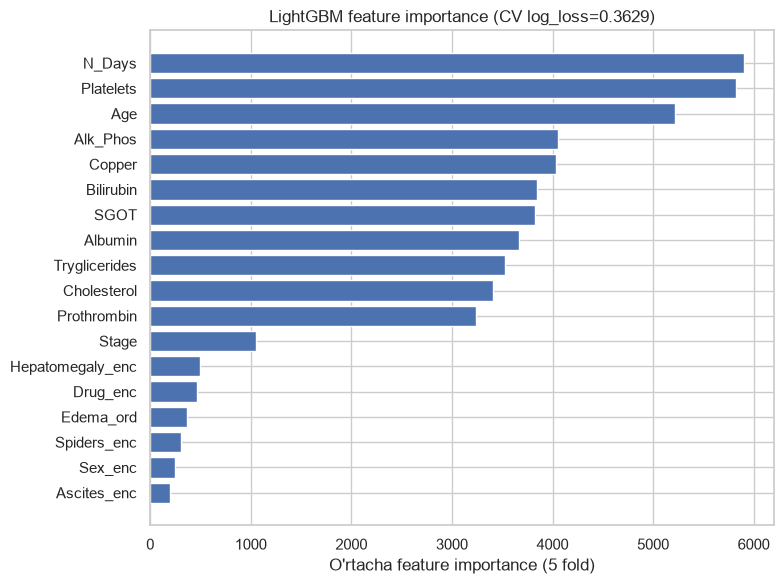

,feature,importance
0,N_Days,5906.4
9,Platelets,5824.0
1,Age,5222.4
6,Alk_Phos,4052.4
5,Copper,4036.2
2,Bilirubin,3848.0


In [10]:
importances = np.array([m.feature_importances_ for m in fold_models])
fi = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": importances.mean(axis=0),
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(fi["feature"][::-1], fi["importance"][::-1], color="#4C72B0")
ax.set_xlabel("O'rtacha feature importance (5 fold)")
ax.set_title(f"LightGBM feature importance (CV log_loss={cv_log_loss:.4f})")
plt.tight_layout()
plt.show()

fi.head(6)

**Javob: yo'q, haddan tashqari dominant emas.** `N_Days` birinchi o'rinda, lekin
`Platelets` va `Age` deyarli bir xil darajada muhim, va yana bir nechta klinik
ustun (`Bilirubin`, `Albumin`, `Copper`, ...) o'xshash ahamiyatga ega. Model
bitta ustunga emas, ko'plab klinik belgilarga tayangan holda bashorat qilmoqda —
bu ishonchli signal.

## 8. Test bashorati va submission

Har bir fold'da o'qitilgan 5 ta modelning test bashoratlarini **o'rtachalaymiz**
(oddiy "5-fold bagging") — bitta modelni butun train'ga qayta o'qitishdan ko'ra
barqarorroq natija beradi, chunki har bir model biroz boshqacha ma'lumot ko'rgan.

In [11]:
test_proba = np.mean(test_proba_folds, axis=0)
test_proba = test_proba / test_proba.sum(axis=1, keepdims=True)  # raqamli aniqlik uchun normalizatsiya

submission = pd.DataFrame(test_proba, columns=[f"Status_{c}" for c in CLASSES], index=test.index)
submission.index.name = ID_COL
submission = submission.reset_index()
submission.to_csv("submission.csv", index=False)

print("submission.csv saqlandi:", submission.shape)
submission.head()

submission.csv saqlandi: (10000, 4)


,id,Status_C,Status_CL,Status_D
0,15000,0.437200,0.002749,0.560052
1,15001,0.856532,0.014500,0.128967
2,15002,0.724602,0.004878,0.270520
3,15003,0.985532,0.000557,0.013910
4,15004,0.181301,0.102836,0.715863


## Xulosalar

1. **Ma'lumot tozalash oddiy, lekin muhim:** 1 ta anomal `Status` qatori topilib
   tashlandi; klinik ustunlardagi ~43-55% null'lar **to'ldirilmadi** (ular tasodifiy
   emas, blok holida yo'q — sun'iy to'ldirish soxta signal beradi).
2. **Kamroq feature ko'proq natija berdi:** `log1p`, nisbat va klinik ball
   feature'lari LightGBM uchun foydali bo'lmadi — faqat sodda kategorial encoding
   yetarli va yaxshiroq natija berdi.
3. **Original (UCI) ma'lumotni qo'shish barqaror yordam berdi** — qo'shimcha 418
   bemor namunasi modelga ko'proq haqiqiy signal berdi.
4. **Giperparametr tuning (Optuna) muhim farq qildi:** `CV 0.3688 -> 0.3629`.
5. **`N_Days` muhim, lekin yagona hukmron feature emas** — model bir nechta
   klinik ko'rsatkichga tayanadi, bu ishonchliroq bashorat degani.
6. Yakuniy CV log loss taxminan **0.363** atrofida — bu qiymat leaderboard
   natijasiga yaqin bo'lishi kutiladi (agar sezilarli CV/LB farqi bo'lsa, buning
   sababi ko'pincha kichik `CL` sinfidagi shovqin bo'ladi, distribution shift emas —
   train/test taqsimotlari EDA'da deyarli bir xil ekani ko'rsatilgan edi).

To'liq tahlil (EDA, feature ablatsiyasi, model taqqoslash) uchun loyihaning
`notebooks/01_eda.ipynb` va `notebooks/03_experiments.ipynb` fayllariga qarang.